<a href="https://colab.research.google.com/github/JustinMann123/EMSC2010_W2_P1_NB1_u8350605.ipynb/blob/main/major_assesment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Greenland Outline and GPS Station Locations

This section will visualize the Greenland ice sheet using gridded data from `GIS_GMB_grid.nc` and overlay the GPS station locations from `GNET_2025.nc` on a `cartopy` map.

### **Problem fraiming**

TALK ABOUT WHAT YOUR QUESTION IS ECT

4 – Clear, well-defined question; scope is appropriate and well justified

## **Methodology**

4 – Methods are appropriate, clearly explained, and explicitly linked to the research question



## **DATA UNDERSTANDING**

4 – Data are loaded, cleaned, and handled sensibly; assumptions and choices are clearly acknowledged


In [101]:
!pip install cartopy

In [102]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Shape of grace_grid_GT: (233, 55, 36)
Units of grace_grid_GT: Gt


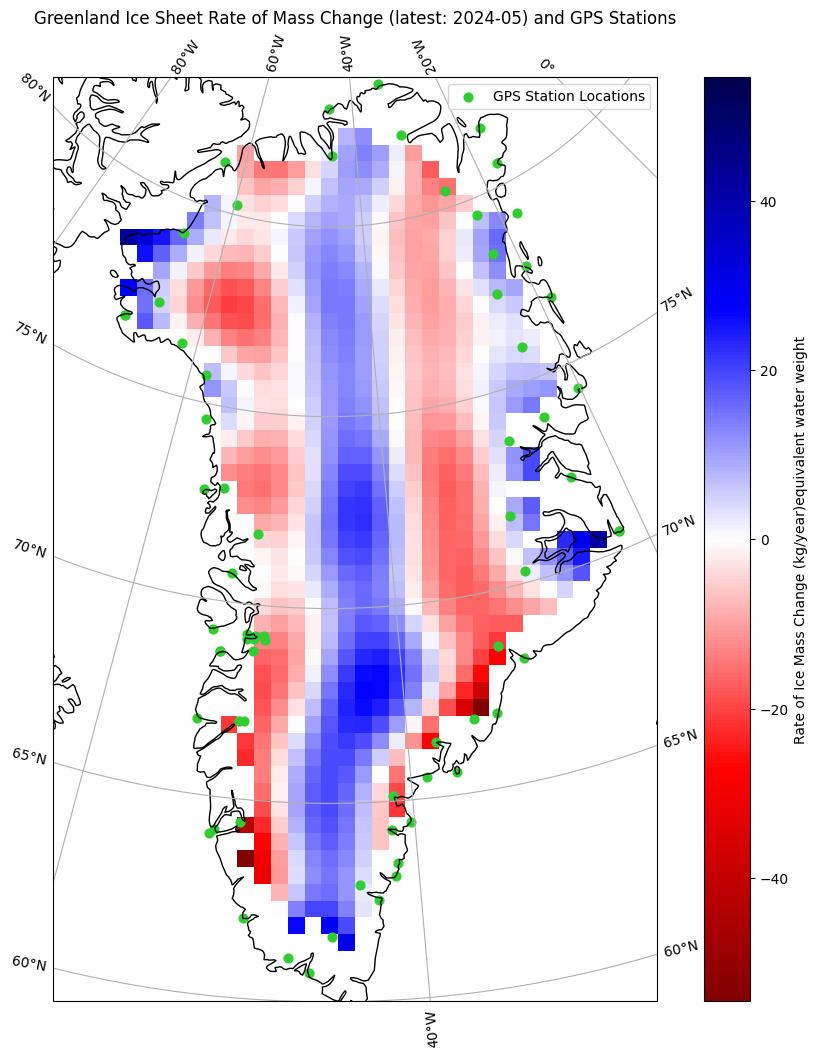

<xarray.DataArray 'dm' (y: 55, x: 36)> Size: 16kB
[1980 values with dtype=float64]
Coordinates:
  * y        (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * x        (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
    time     datetime64[ns] 8B 2002-04-18
Attributes:
    actual_range:   [-12610.9   9044. ]
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2
<xarray.DataArray 'dm' (y: 55, x: 36)> Size: 16kB
[1980 values with dtype=float64]
Coordinates:
  * y        (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * x        (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
    time     datetime64[ns] 8B 2024-05-16T12:00:00
Attributes:
    actual_range:   [-12610.9   9044. ]
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2


In [109]:
### Ai statment--- i had ai help mesubstaitlly creat this as intergrating both gnet loactions
## greenland mask from the gnet data and grace measurments was diffcult.




print("Shape of grace_grid_GT:", grace_grid_GT.shape)
print("Units of grace_grid_GT:", "Gt")
# Load the datasets (re-loading to ensure they are in scope for this cell)
grace_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')
gnet = xr.open_dataset('/content/GNET_2025.nc')

grace_grid_GT = (grace_grid["dm"] * grace_grid["area"]) / 1e12

# Prepare grid data for plotting: calculate the rate of mass change (dm/dt)
# The .diff('time') reduces the 'time' dimension by 1. We then select the last available time slice.
rate_of_mass_change = (grace_grid_GT.diff('time') / (grace_grid_GT.time.diff('time').dt.days / 365.25))

# Select the last time step for plotting the current rate of change
latest_rate_data = rate_of_mass_change.isel(time=-1)

# Create a figure and axes with the appropriate Cartopy projection
plt.figure(figsize=(12, 12))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# Plot the gridded mass change rate data
# We use pcolormesh to plot the 2D gridded data
latest_rate_data.plot.pcolormesh(
    ax=ax,
    x='x', y='y',
    transform=ccrs.NorthPolarStereo(central_longitude=-45), # The data's projection
    cmap='seismic_r',
    cbar_kwargs={'label': f'Rate of Ice Mass Change (kg/year)equivalent water weight'},
    add_colorbar=True
)

# Add geographical features
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Plot station locations from GNET_2025.nc
# Check if 'lat' and 'lon' exist in ds_gnet
if 'lat' in gnet.variables and 'lon' in gnet.variables:
    ax.scatter(
        gnet['lon'], gnet['lat'],
        transform=ccrs.PlateCarree(), # Stations are in lat/lon, so use PlateCarree for source coordinates
        color='limegreen', s=40, label='GPS Station Locations' # Changed 'neonGreen' to 'limegreen'
    )
    plt.legend()
else:
    print("Latitude and Longitude variables not found in GNET_2025.nc")

# Set title, reflecting the rate and the time of the latest data point
plt.title(f'Greenland Ice Sheet Rate of Mass Change (latest: {latest_rate_data.time.dt.strftime("%Y-%m").values}) and GPS Stations')

plt.show()



### show first and last grace signal
print(grace_grid.dm.isel(time=0))
print(grace_grid.dm.isel(time=-1))

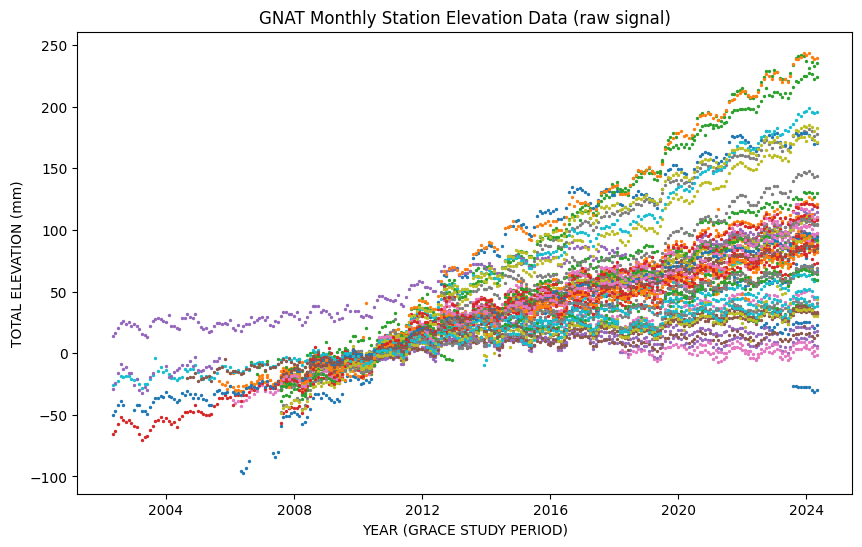

In [104]:
#### plotting raw GNET data
##AI assited with this

## what needs to be done

#Step 1

#open dataset

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib

gnet = xr.open_dataset('/content/GNET_2025.nc')

# step 2 isolate variables

time     = pd.to_datetime(gnet['time'].values)
up       = gnet['up'].values
stations = gnet['station'].values

# clean data to match grace data
##look at previous cell for print function
### start 2002-04-18 End 2024-05-16

study_start = pd.Timestamp('2002-04-18')
study_end   = pd.Timestamp('2024-05-16')

### set a common index
time_index = pd.date_range(study_start, study_end, freq='MS')

### create a new array- for deomstration of what raw data looks like

unormalised = []

## this part is hard as not all of data satrt at the same time and there are 61 diffret GPS stations
## for this reason a loop function needed to be used to loop throught and trim anything out of these bounds

for i, stn in enumerate(stations):
    # (a) slice to GRACE period
    series = pd.Series(up[i], index=time)
    series = series[(series.index >= study_start) & (series.index <= study_end)]

## need to resample the daily measurments to avg monthly as we daily is very noisy--Limitation?

    monthly_Unormalised = series.resample("MS").mean()

### Figure out what this is doing i dare say this is staring them all somwhere??
    monthly1_Unormalised = monthly_Unormalised.reindex(time_index)

#### save into the array

    unormalised.append(monthly1_Unormalised.values)

unormalised_array = np.array(unormalised)

#### with new array created that contians all gnet station monthly elevation data within study periods
#### plot to show for the A3 poster
### this is also hard as there are 61 stations dat that needs to be plotted on that graph
## therfore we need to do a loop plt.scatter

plt.figure(figsize=(10, 6))
for i, stn_data in enumerate(unormalised_array):
  plt.scatter(time_index, stn_data,s=2)
  plt.xlabel('YEAR (GRACE STUDY PERIOD)')
  plt.ylabel('TOTAL ELEVATION (mm)')
  plt.title('GNAT Monthly Station Elevation Data (raw signal)')

# Next step Normalise and avg all GNET data prior to fitting

In [106]:
## the steps complted in this were assited by gemini
### due to gnet data coming in the form of a netcdf .nc
#i thought i would be best to keep it as a xarray instead of going xarray -> pandas -> numpy
# Supposeldy xarray is the best way to store .nc files but ai was needed to assit witht eh for loop functions

gnet = xr.open_dataset('/content/GNET_2025.nc')
up = gnet['up'] # Ensure 'up' is an xarray.DataArray

study_start = pd.Timestamp('2002-04-18')
study_end   = pd.Timestamp('2024-05-16')
time_index = pd.date_range(study_start, study_end, freq='MS')

stations = up.sizes["station"]

unormalised = xr.DataArray(
    np.full((stations, len(time_index)), np.nan),
    dims=["station", "time"],
    coords={"station": up["station"], "time": time_index}
)

for i in range(stations):

    series = up.isel(station=i)

    # convert to pandas for resampling (needed for irregular time)
    series = series.to_pandas()

    series = series[(series.index >= study_start) & (series.index <= study_end)]

    monthly = series.resample("MS").mean()

    monthly = monthly.reindex(time_index)

    unormalised[i, :] = monthly.values

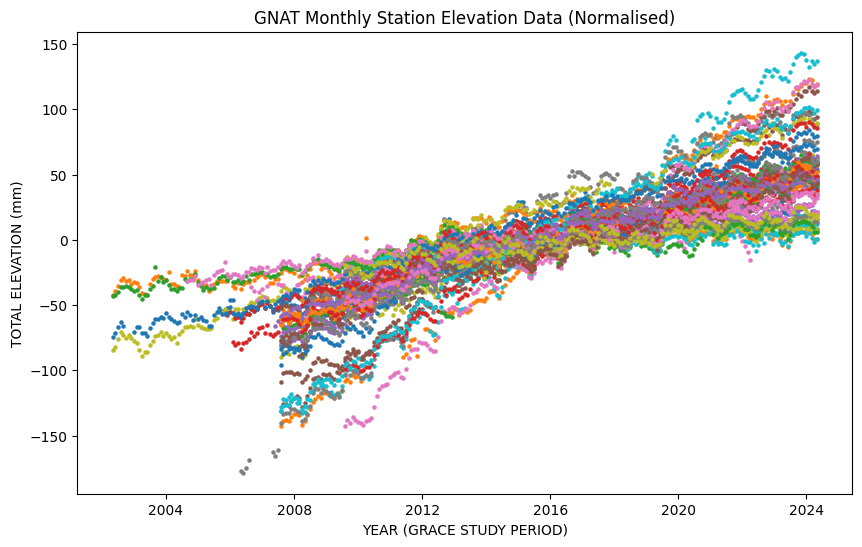

In [107]:
### Simular to the last step but wiht extra step involved

normalised = [] # This list will now hold xarray.DataArray objects

for i in range(unormalised.sizes["station"]):

    station_data = unormalised.isel(station=i)

    if station_data.count() < 60:
        continue

    station_norm = station_data - station_data.mean()

    normalised.append(station_norm) # Append the xarray.DataArray directly


normalised_gnet = xr.concat(normalised, dim='station') # Concatenate into a new xarray.DataArray

plt.figure(figsize=(10, 6))
# If normalised_gnet is an xarray DataArray, iteration typically gives the first dimension's elements.
# So stn_data will be a DataArray for each station.
for i, stn_data in enumerate(normalised_gnet):
  plt.scatter(time_index, stn_data,s=5)
  plt.xlabel('YEAR (GRACE STUDY PERIOD)')
  plt.ylabel('TOTAL ELEVATION (mm)')
  plt.title('GNAT Monthly Station Elevation Data (Normalised)')

### Calculate and plot the average monthly elevation change across all GPS stations

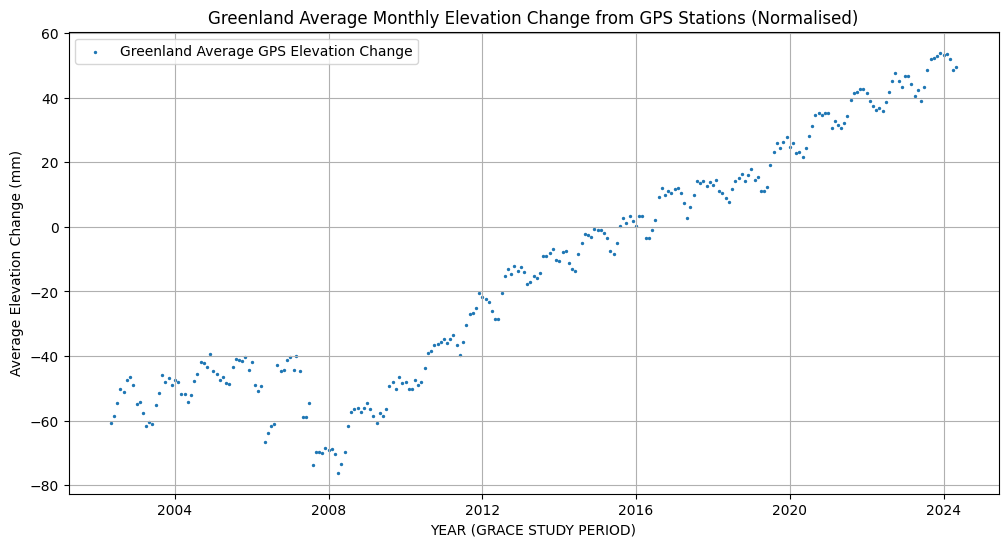

In [108]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

monthly_means = []

# normalised_gnet is now an xarray.DataArray (stations, time_steps)
# Iterate over the time dimension of the normalised_gnet xarray.DataArray
for t_idx in range(normalised_gnet.sizes['time']):
    # Select all stations for the current time step and calculate the mean across stations
    # Use .isel(time=t_idx) to select the time slice
    # Then use .mean(dim='station') to calculate the mean across the station dimension
    mean_at_time_t = normalised_gnet.isel(time=t_idx).mean(dim='station')
    monthly_means.append(mean_at_time_t.item()) # .item() extracts the scalar value

monthly_means = np.array(monthly_means)

# Plot the averaged time series
plt.figure(figsize=(12, 6))
plt.scatter(time_index,monthly_means, label='Greenland Average GPS Elevation Change',s=2)
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Average Elevation Change (mm)')
plt.title('Greenland Average Monthly Elevation Change from GPS Stations (Normalised)')
plt.grid(True)
plt.legend()
plt.show()

### Calculating Average Monthly Elevation Change using a Loop

## convert normalised data to an averaged elastic and GIA rate. ie a rate hopfully representaive of the entire grrenland land mass. 1

## **Data preperation complete**





In [72]:
grace_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')

# Calculate mass in kilograms for each grid cell
grace_mass_kg = grace_grid.dm * grace_grid.area # This is the new xarray DataArray
grace_mass_GT = grace_mass_kg/1e12


# step 2 isolate variables

time_grace  = pd.to_datetime(grace_mass_GT['time'].values)
# `dm` is no longer used directly in its original form here
x_grace = grace_mass_GT['x'].values

# clean data to match grace data
##look at previous cell for print function
### start 2002-04-18 End 2024-05-16

study_start = pd.Timestamp('2002-04-18')
study_end   = pd.Timestamp('2024-05-16')

### set a common index
time_index = pd.date_range(study_start, study_end, freq='MS')

### create a new array- for deomstration of what raw data looks like

unormalised_grace = []

## This part is adapted to extract a time series for each x-coordinate, averaged over the y-dimension.
## Now using the area-weighted `grace_mass_kg`.

for x_dim_idx in range(len(x_grace)): # Iterate over each x-coordinate index
    # Extract the time series for the current x-coordinate, averaged over y, using grace_mass_kg
    series_grace = grace_mass_kg.isel(x=x_dim_idx).mean(dim='y').to_pandas()

    series_grace = series_grace[(series_grace.index >= study_start) & (series_grace.index <= study_end)]

    grace_time_fix = series_grace.resample("MS").mean()

    grace_time_fix = grace_time_fix.reindex(time_index)

    unormalised_grace.append(grace_time_fix.values)

unormalised_grace = np.array(unormalised_grace)

In [73]:
### normalise the grace data now

# unormalised_grace is a numpy.ndarray. Convert it to an xarray.DataArray for proper attribute and method access.
unormalised_grace_xr = xr.DataArray(
    unormalised_grace,
    coords={'x': x_grace, 'time': time_index}, # x_grace and time_index should be available from previous cells
    dims=['x', 'time']
)

normalised_grace = [] # This list will now hold xarray.DataArray objects

# Iterate over the 'x' dimension of the xarray DataArray
for i in range(unormalised_grace_xr.sizes["x"]):

    mass_data = unormalised_grace_xr.isel(x=i)

    # The condition `mass_data.count() < 0` is logically incorrect as count cannot be negative.
    # It's removed to prevent future issues and improve code clarity.
    # If the intent was to skip series with all NaNs, a different check would be needed.

    mass_norm = mass_data - mass_data.mean()

    normalised_grace.append(mass_norm) # Append to normalised_grace, not 'normalised' which is for GNET data


# Concatenate the normalized GRACE data into a single xarray.DataArray
# Use 'x' as the new dimension name, consistent with the iteration.
normalised_grace_data_array = xr.concat(normalised_grace, dim='x') # Renamed to reflect GRACE data

plt.figure(figsize=(10, 6))



<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

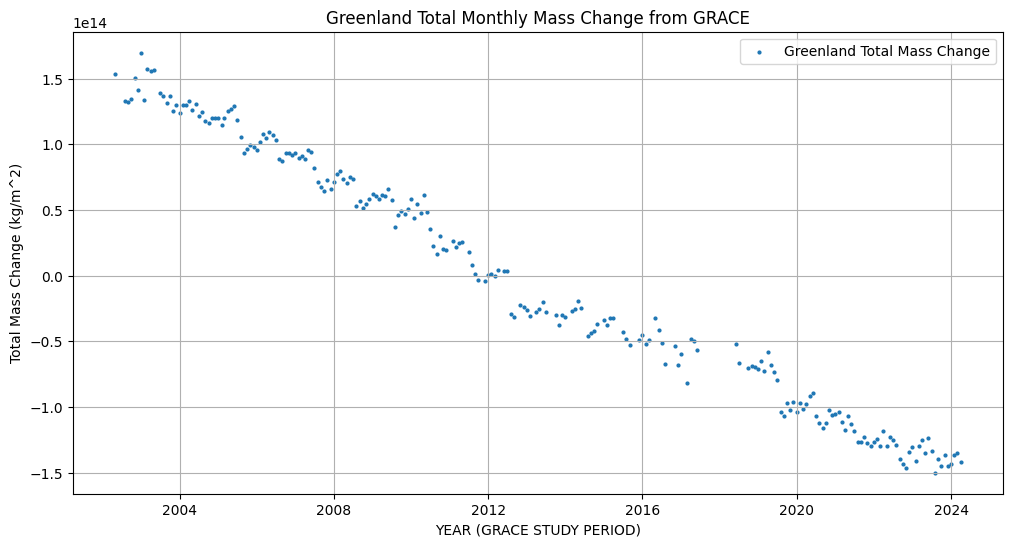

In [74]:
import numpy as np
# Initally i tried to use the synthetic time_index created at the start but ai
# says grace data dosnt work like that so it best just to set a its own x variable ie 'time'
grace_time_values = normalised_grace_data_array['time'].values


#simualr to previous loops keeping it in xarray we are saying for time in grace_grid
#sum all dm ie mass across greenland...skipping any na values and put into the xarray.array time_series

time_series = []
for t_idx in range(normalised_grace_data_array.sizes['time']):
  kgm2= normalised_grace_data_array.isel(time=t_idx)
  # Check if all values in the current time slice are NaN
  if kgm2.isnull().all().item():
      value = np.nan # Assign NaN if all are NaN
  else:
      value = kgm2.sum(skipna=True) # Otherwise, sum non-NaN values
  time_series.append(value.item() if not np.isnan(value) else np.nan)

### same as previous cells plot the new array values.

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(grace_time_values, time_series, marker='o', linestyle='-', s=4, label='Greenland Total Mass Change')
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Total Mass Change (kg/m^2)')
plt.title('Greenland Total Monthly Mass Change from GRACE')
plt.grid(True)
plt.legend()
plt.show()

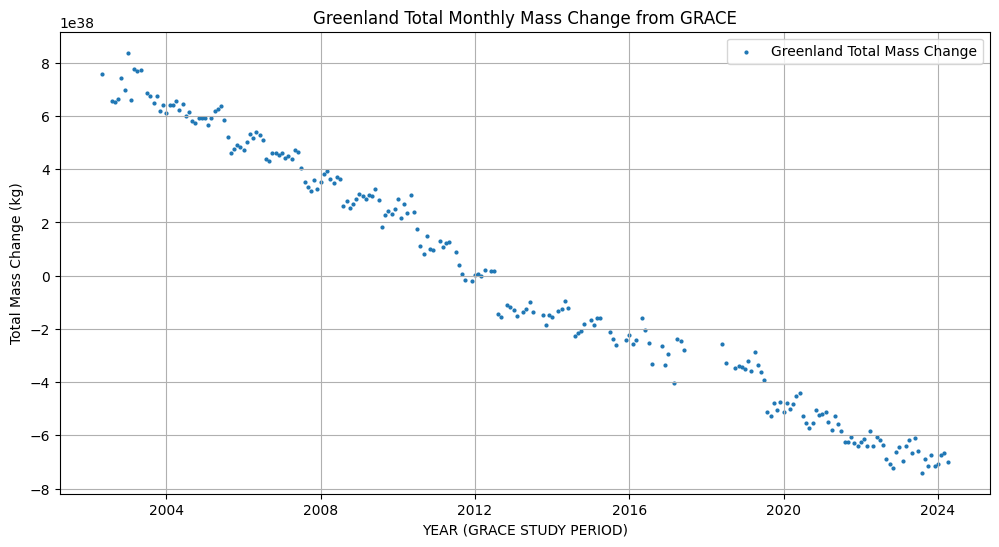

In [75]:
import numpy as np
Grace_area = np.array(time_series) * total_mascon_area_m2
monthly_grace_GT= np.array(Grace_area)/1e-12



plt.figure(figsize=(12, 6))
plt.scatter(time_index, monthly_grace_GT, marker='o', linestyle='-', s=4, label='Greenland Total Mass Change')
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Total Mass Change (kg)')
plt.title('Greenland Total Monthly Mass Change from GRACE')
plt.grid(True)
plt.legend()
plt.show()

### NEED TO DETERMIN IF THIS IS CORRECT IE THE CODE ABOVE WHERE I NORMALISE OR F I DONT

In [88]:
monthly_grace_xr = (grace_grid["dm"] * grace_grid["area"]).sum(dim=["x","y"], skipna=True) / 1e12

monthly_grace_pd = monthly_grace_xr.to_pandas()

# force GRACE onto monthly-start timestamps
monthly_grace_pd = monthly_grace_pd.resample("MS").mean()

# now align
monthly_grace_aligned = monthly_grace_pd.reindex(time_index)

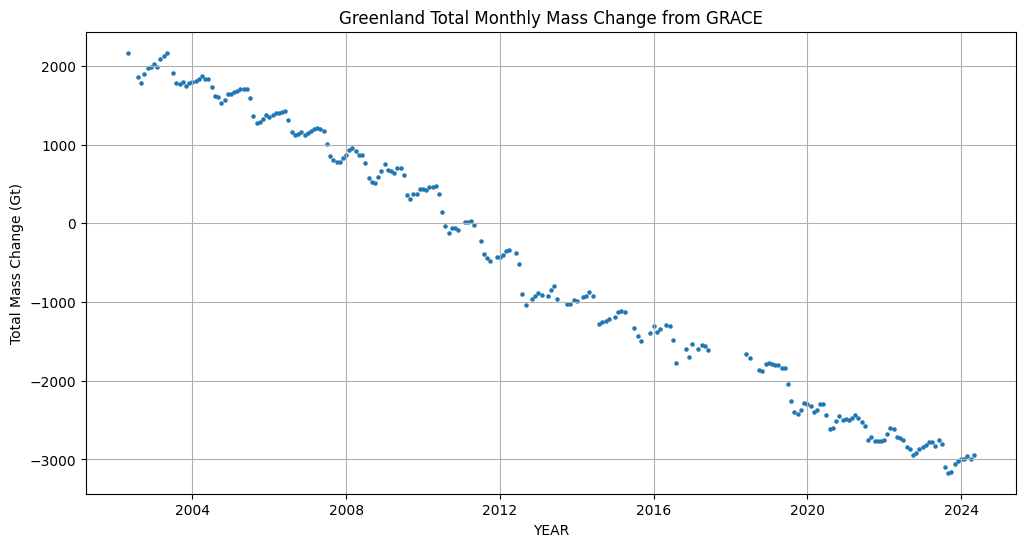

In [93]:
plt.figure(figsize=(12,6))

plt.scatter(time_index, monthly_grace_aligned, s=5)

plt.xlabel("YEAR")
plt.ylabel("Total Mass Change (Gt)")
plt.title("Greenland Total Monthly Mass Change from GRACE")
plt.grid(True)

plt.show()

## **Interpretation and critical thinking**

## **Part 2 - Individual reflection 500 words**